In [95]:
import pandas as pd

df1=pd.DataFrame()
df1=pd.read_excel('../data/5.xlsx')
df1=df1.dropna()

#df_ant - projection to z axis for anterior view
df_ant = df1[['l_hip_x','l_hip_y','l_knee_x','l_knee_y','l_ankle_x','l_ankle_y']]

pd.set_option('mode.chained_assignment', None)
df_ant['l_tibia_x'] = df_ant['l_knee_x'] - df_ant['l_ankle_x']
df_ant['l_tibia_y'] = df_ant['l_knee_y'] - df_ant['l_ankle_y']
df_ant['l_femur_x'] = df_ant['l_hip_x'] - df_ant['l_knee_x']
df_ant['l_femur_y'] = df_ant['l_hip_y'] - df_ant['l_knee_y']

#lateral view
df_lat = df1[['torso_y', 'torso_z', 'waist_y','waist_z','l_hip_y','l_hip_z','l_knee_y','l_knee_z','l_ankle_y','l_ankle_z']]

df_lat['tor_wai_y'] = df_lat['torso_y'] - df_lat['waist_y']
df_lat['tor_wai_z'] = df_lat['torso_z'] - df_lat['waist_z']
df_lat['l_hip_wai_y'] = df_lat['waist_y'] - df_lat['l_hip_y']
df_lat['l_hip_wai_z'] = df_lat['waist_z'] - df_lat['l_hip_z']
df_lat['l_tibia_y'] = df_lat['l_knee_y'] - df_lat['l_ankle_y']
df_lat['l_tibia_z'] = df_lat['l_knee_z'] - df_lat['l_ankle_z']

In [96]:
def angle_v2(vec1, vec2):
    #compute angle between 2 vectors. ... from google
    #import math
    import numpy as np

    np.array 
    
    # 각 벡터의 각도 계산 (x축 기준)
    angle1 = np.arctan2(vec1[:,1], vec1[:,0])
    angle2 = np.arctan2(vec2[:,1], vec2[:,0])

    # 두 각도의 차이 계산
    angle_diff_rad = angle2 - angle1

    # 절대값 및 360도 조정 (필요에 따라)
    angle_diff_deg = np.degrees(angle_diff_rad)
    #angle_diff_deg = np.where( angle_diff_deg < 0, angle_diff_deg + 360, angle_diff_deg )

    return angle_diff_deg


In [97]:
import numpy as np
from scipy.signal import argrelextrema
import scipy

x = df1['torso_y'].rolling(window=25).mean().values
minima_indices = argrelextrema(x, np.less)
m = minima_indices[0]
m

array([ 50, 137, 212, 283, 354])

In [98]:
for i in range( m.size):
    print(i, m[i])
    mi = m[i]
    print(df_ant[['l_ankle_x','l_knee_x','l_hip_x']].loc[mi])
    print(df_ant[['l_ankle_y','l_knee_y','l_hip_y']].loc[mi])
    
    print('ankle',df_ant.loc[mi]['l_ankle_x'],  df_ant.loc[mi]['l_ankle_y'] )
    print('knee',df_ant.loc[mi]['l_knee_x'],  df_ant.loc[mi]['l_knee_y'] )
    print('hip',df_ant.loc[mi]['l_hip_x'],  df_ant.loc[mi]['l_hip_y'] )

0 50
l_ankle_x    241.497015
l_knee_x     177.595415
l_hip_x       80.458689
Name: 50, dtype: float64
l_ankle_y   -1098.443206
l_knee_y     -756.464375
l_hip_y      -462.574740
Name: 50, dtype: float64
ankle 241.4970149543171 -1098.443206212454
knee 177.5954152246094 -756.4643753688434
hip 80.45868909134259 -462.5747402660318
1 137
l_ankle_x    238.815171
l_knee_x     182.775707
l_hip_x       80.114051
Name: 137, dtype: float64
l_ankle_y   -1027.525392
l_knee_y     -741.203439
l_hip_y      -380.579906
Name: 137, dtype: float64
ankle 238.8151711511173 -1027.525391784763
knee 182.7757073417163 -741.2034391121936
hip 80.11405055755023 -380.5799060892847
2 212
l_ankle_x    254.116223
l_knee_x     180.886306
l_hip_x       89.116453
Name: 212, dtype: float64
l_ankle_y   -1035.455119
l_knee_y     -742.814403
l_hip_y      -416.543105
Name: 212, dtype: float64
ankle 254.1162230436533 -1035.455119419752
knee 180.8863061846067 -742.8144030447269
hip 89.11645310292512 -416.5431053797231
3 283
l_an

In [99]:
df_ant.loc[m,:][['l_hip_x','l_hip_y']]

,l_hip_x,l_hip_y
50,80.458689,-462.574740
137,80.114051,-380.579906
212,89.116453,-416.543105
283,72.643376,-388.498787
354,74.442015,-375.570874


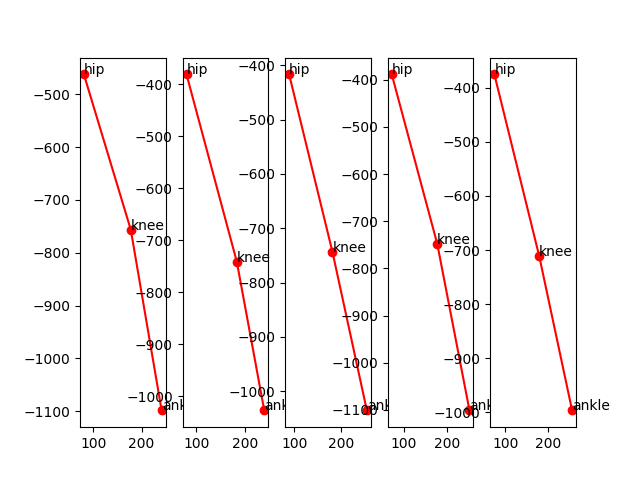

In [100]:
fig, ax = plt.subplots(1,m.size)
for i in range( m.size):
    mi = m[i]
    ax[i].plot( df_ant[['l_ankle_x','l_knee_x','l_hip_x']].loc[mi].values, df_ant[['l_ankle_y','l_knee_y','l_hip_y']].loc[mi].values,"o-r" )
    ax[i].text( df_ant.loc[mi]['l_ankle_x'],  df_ant.loc[mi]['l_ankle_y'] , "ankle" )
    ax[i].text( df_ant.loc[mi]['l_knee_x'],  df_ant.loc[mi]['l_knee_y'], "knee" )
    ax[i].text( df_ant.loc[mi]['l_hip_x'],  df_ant.loc[mi]['l_hip_y'], "hip" )
    
plt.show()

In [101]:
#knees move inward, outward   : anterior view
#+ means outward (o형),  - means inward (x형 )  : it seems that left and right signs in the visualization data  are swapped. 
angle_v2(df_ant[['l_tibia_x','l_tibia_y']].loc[m,:].values,       df_ant[['l_femur_x','l_femur_y']].loc[m,:].values     )

array([7.70567477, 4.8164498 , 1.66052902, 4.38786165, 2.24279842])

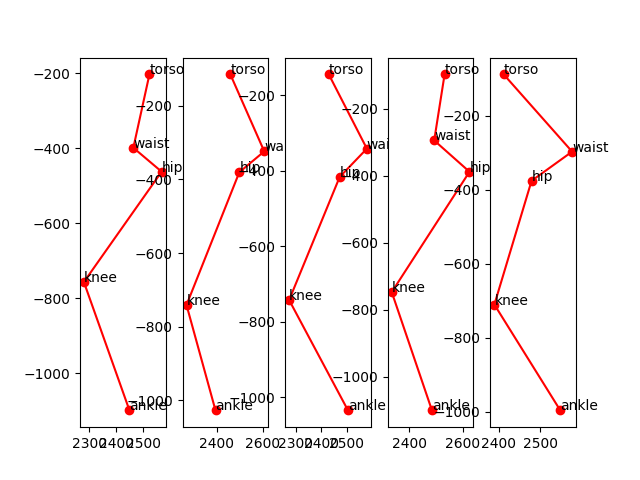

In [103]:
fig, ax = plt.subplots(1,m.size)
for i in range( m.size):
    mi = m[i]
    ax[i].plot( df_lat[['torso_z', 'waist_z','l_hip_z','l_knee_z','l_ankle_z']].loc[mi].values, 
                df_lat[['torso_y', 'waist_y','l_hip_y','l_knee_y','l_ankle_y']].loc[mi].values,"o-r" )
    ax[i].text( df_lat.loc[mi]['torso_z'],  df_lat.loc[mi]['torso_y'] , "torso" )
    ax[i].text( df_lat.loc[mi]['waist_z'],  df_lat.loc[mi]['waist_y'], "waist" )
    ax[i].text( df_lat.loc[mi]['l_hip_z'],  df_lat.loc[mi]['l_hip_y'], "hip" )
    ax[i].text( df_lat.loc[mi]['l_knee_z'],  df_lat.loc[mi]['l_knee_y'], "knee" )
    ax[i].text( df_lat.loc[mi]['l_ankle_z'],  df_lat.loc[mi]['l_ankle_y'], "ankle" )
    
plt.show()

In [104]:
#low back arch
# "large + " value means Excessive low back arch
angle_v2(df_lat[['tor_wai_z', 'tor_wai_y']].loc[m,:].values, df_lat[['l_hip_wai_z','l_hip_wai_y']].loc[m,:].values)

array([ 75.72758016, -97.96987661, -91.68442892,  65.79522824,
       -89.90668753])

In [105]:
#torso lean forward  : lateral view
# large plus value means excessive forward lean

angle_v2(df_lat[['l_tibia_z','l_tibia_y']].loc[m,:].values, df_lat[['tor_wai_z','tor_wai_y']].loc[m,:].values)

array([-43.29436668,  11.46565555,  -1.10262582, -34.1869942 ,
         9.28869366])

In [58]:
df_ant[['l_ankle_x','l_knee_x','l_hip_x']].loc[mi].values[0]

np.float64(138.6611)

In [57]:
mi

np.int64(60)

In [5]:
df_ant[['l_ankle_x','l_knee_x','l_hip_x']].head(1).values

array([[139.9366 ,  99.13966,  59.56746]])

In [6]:
df_ant[['l_ankle_y','l_knee_y','l_hip_y']].head(1).values

array([[-954.6445, -632.0627, -265.5242]])

In [28]:
df_ant[['l_ankle_x','l_knee_x','l_hip_x']].head(1).values[0]

array([139.9366 ,  99.13966,  59.56746])

In [22]:
x_values

[[1, 4], [2, 1]]

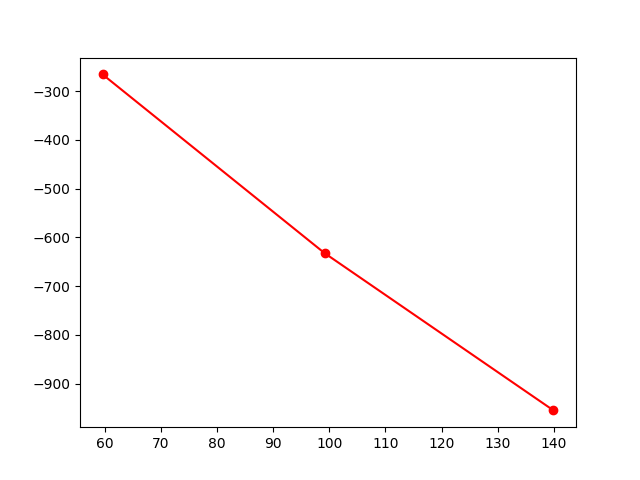

In [29]:

import matplotlib.pyplot as plt
fig, axs = plt.subplots()
plt.plot(df_ant[['l_ankle_x','l_knee_x','l_hip_x']].head(1).values[0], df_ant[['l_ankle_y','l_knee_y','l_hip_y']].head(1).values[0],"o-r")

plt.show()

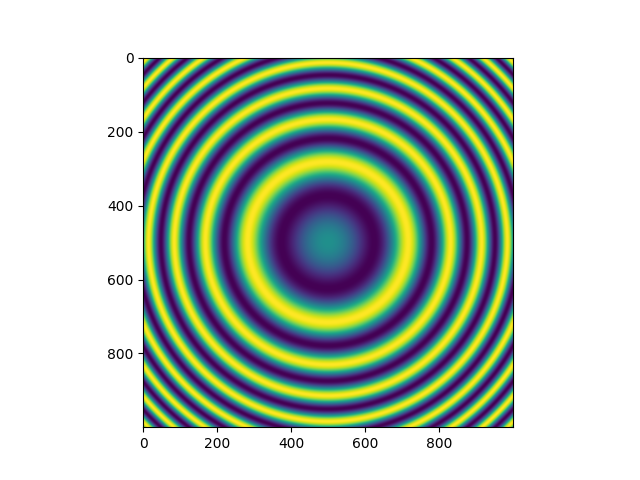

In [2]:
# from https://thepythoncodingbook.com/basics-of-data-visualisation-in-python-using-matplotlib/
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
x = np.linspace(-5, 5, 1000)
y = np.linspace(-5, 5, 1000)
X, Y = np.meshgrid(x, y)
fig, ax = plt.subplots()
images = []
for a in np.linspace(-np.pi, np.pi, 50):
    Z = np.sin(X ** 2 + Y ** 2 - a)
    img = ax.imshow(Z)
    break
    images.append([img])
output = animation.ArtistAnimation(fig, images, interval=50, blit=True)
plt.show()

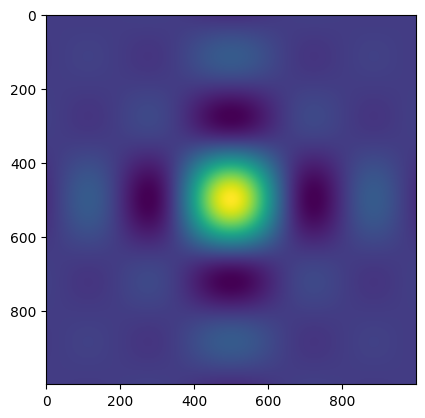

In [12]:
import matplotlib.pyplot as plt
import numpy as np
x = np.linspace(-10, 10, 1000)
y = np.linspace(-10, 10, 1000)
X, Y = np.meshgrid(x, y)
Z = (np.sin(X) / X) * (np.sin(Y) / Y)
plt.imshow(Z)
plt.show()

In [11]:
plt.show()

In [18]:
images[0][0]